In [16]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

FileUpload(value=(), accept='.png', description='Upload')

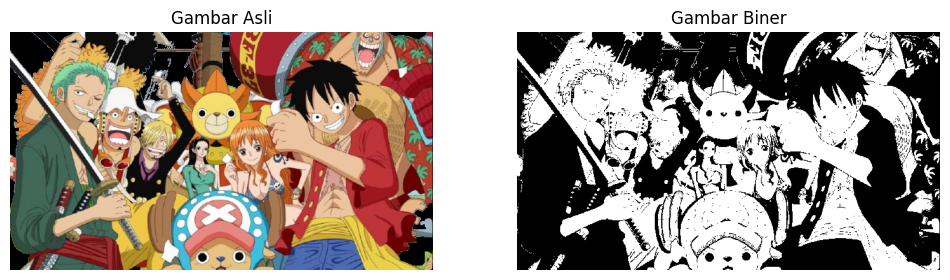

In [ ]:
uploader = widgets.FileUpload(accept='.png', multiple=False)
display(uploader)

In [18]:
def convert_to_binary(image_path, threshold=128):
    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)
    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    
    # Thresholding
    binary = np.where(gray < threshold, 0, 255).astype(np.uint8)

    # Membuat image biner
    binary_img = Image.fromarray(binary, mode='L')
    
    return img, binary_img

In [19]:
def process_file(change):
    if uploader.value:
        # Ambil file upload
        file_info = uploader.value[0]
        content = file_info['content']
        filename = file_info['name']
        
        # Simpan file ke disk
        with open(filename, 'wb') as f:
            f.write(content)
        
        # Konversi
        original_img, binary_img = convert_to_binary(filename)
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(original_img)
        axs[0].set_title("Gambar Asli")
        axs[0].axis('off')
        
        axs[1].imshow(binary_img, cmap='gray')
        axs[1].set_title("Gambar Biner")
        axs[1].axis('off')
        
        plt.show()
    else:
        print("Belum ada file yang diupload.")

In [20]:
uploader.observe(process_file, names='value')